In [ ]:
#1. Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#2. Load Dataset
df = pd.read_csv('movies_metadata.csv', low_memory=False)

df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
#3. Basic Data Understanding
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [ ]:
#4. Select Important Columns
df = df[['title', 'overview', 'genres', 'vote_average', 'vote_count']]

df.head()

,title,overview,genres,vote_average,vote_count
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,5415.0
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,2413.0
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,92.0
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,34.0
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,173.0


In [ ]:
#5. Handle Missing Values
df['overview'] = df['overview'].fillna('')
df = df.dropna(subset=['title'])

df = df.reset_index(drop=True)

df.isnull().sum()

title           0
overview        0
genres          0
vote_average    0
vote_count      0
dtype: int64

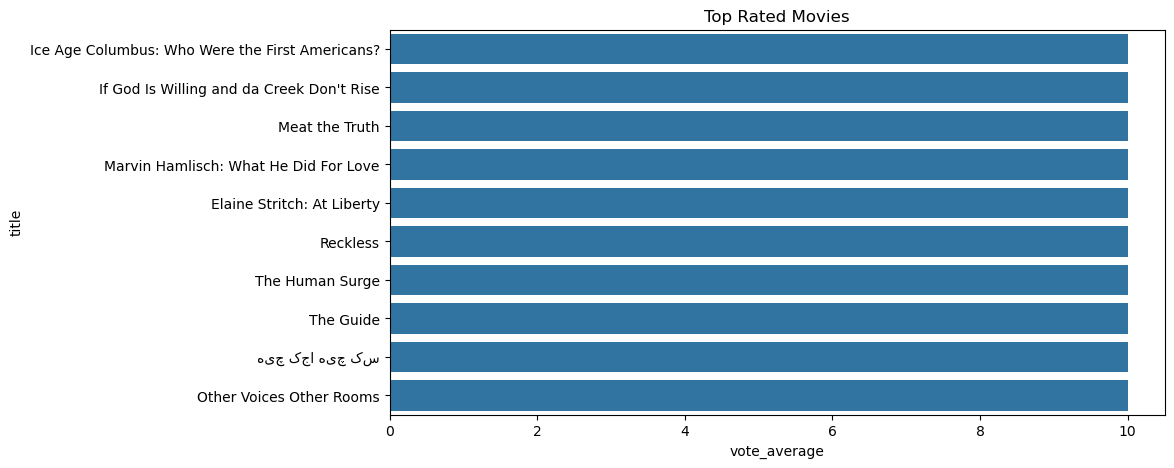

In [ ]:
#6. Exploratory Data Analysis
#Top Rated Movies
top_movies = df.sort_values(by='vote_average', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_movies['vote_average'], y=top_movies['title'])
plt.title("Top Rated Movies")
plt.show()

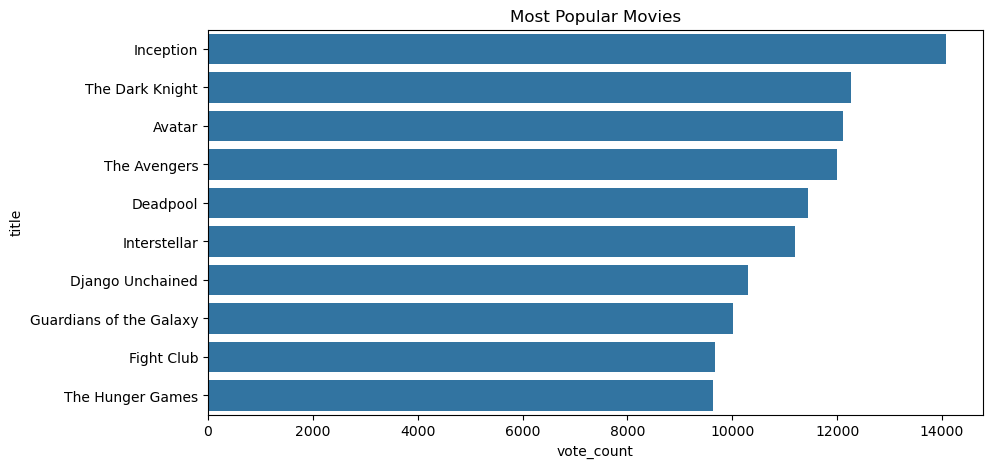

In [ ]:
#Most Popular Movies
popular_movies = df.sort_values(by='vote_count', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=popular_movies['vote_count'], y=popular_movies['title'])
plt.title("Most Popular Movies")
plt.show()

In [ ]:
# Clean Genres Column
import ast

def clean_genres(x):
    try:
        genres = ast.literal_eval(x)
        return " ".join([i['name'] for i in genres])
    except:
        return ""

df['genres'] = df['genres'].apply(clean_genres)

# Combine Features
df['combined_features'] = df['overview'] + " " + df['genres']

# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

tfidf_matrix.shape

(45460, 75827)

In [ ]:
# Create Index Mapping
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [ ]:
def recommend_movies(title):
    
    if title not in indices:
        return "Movie not found in dataset"
    
    idx = indices[title]
    
    # Compute similarity only for selected movie
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    
    # Get top 10 similar movies
    top_indices = sim_scores.argsort()[-11:-1][::-1]
    
    return df['title'].iloc[top_indices]

In [ ]:
print("Recommendations for Toy Story:\n")
print(recommend_movies("Toy Story"))

Recommendations for Toy Story:

15348                                     Toy Story 3
2997                                      Toy Story 2
24521                                       Small Fry
10301                          The 40 Year Old Virgin
23841                     Andy Hardy's Blonde Trouble
29200                                      Hot Splash
43421                Andy Kaufman Plays Carnegie Hall
42715    Andy Peters: Exclamation Mark Question Point
38470    Superstar: The Life and Times of Andy Warhol
8327                                        The Champ
Name: title, dtype: object


In [ ]:
import pickle

pickle.dump(tfidf_matrix, open('tfidf_matrix.pkl', 'wb'))
pickle.dump(indices, open('indices.pkl', 'wb'))